In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

Série Temporal -> Sucessão de eventos no tempo e que dependem do tempo
* Tendência - Direção
* Sazonalidade - Recorrência das oscilações
* Resíduo - O que sobra do sinal

Regressão Linear -> Função que representaria uma reta, não sendo realista com as alterações de tempo e variáveis

In [2]:
url_eletric = "https://raw.githubusercontent.com/JulianaMoretto/Postech-data-analytics/refs/heads/main/Machine-Learning/Electric_Production.csv"
eletric = pd.read_csv(url_eletric)

In [3]:
eletric.head() #se observar o index é o 0/1/2/3/4

,DATE,Value
0,01-01-1985,72.5052
1,02-01-1985,70.6720
2,03-01-1985,62.4502
3,04-01-1985,57.4714
4,05-01-1985,55.3151


In [4]:
eletric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    397 non-null    object 
 1   Value   397 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.3+ KB


In [5]:
eletric.index = pd.to_datetime(eletric.DATE, format = "%m-%d-%Y") #indexar os dados de data/tempo

In [6]:
eletric.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 397 entries, 1985-01-01 to 2018-01-01
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DATE    397 non-null    object 
 1   Value   397 non-null    float64
dtypes: float64(1), object(1)
memory usage: 9.3+ KB


In [7]:
eletric.drop("DATE",axis=1,inplace=True) #dropar a coluna de date que estava como object

In [8]:
eletric.head()

,Value
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


In [9]:
eletric.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 397 entries, 1985-01-01 to 2018-01-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Value   397 non-null    float64
dtypes: float64(1)
memory usage: 6.2 KB


In [10]:
eletric.describe()

,Value
count,397.000000
mean,88.847218
std,15.387834
min,55.315100
25%,77.105200
50%,89.779500
75%,100.524400
max,129.404800


In [11]:
eletric.loc["1985-04-01"] #possível buscar pelo index

,1985-04-01
Value,57.4714


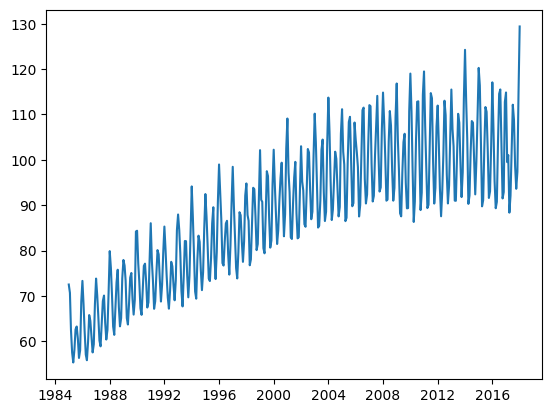

In [13]:
plt.plot(eletric.index, eletric.Value)
#mesmo tendo variações (sobe e desce), vemos que durante o tempo teve um crescimento

In [14]:
resultados = seasonal_decompose(eletric)

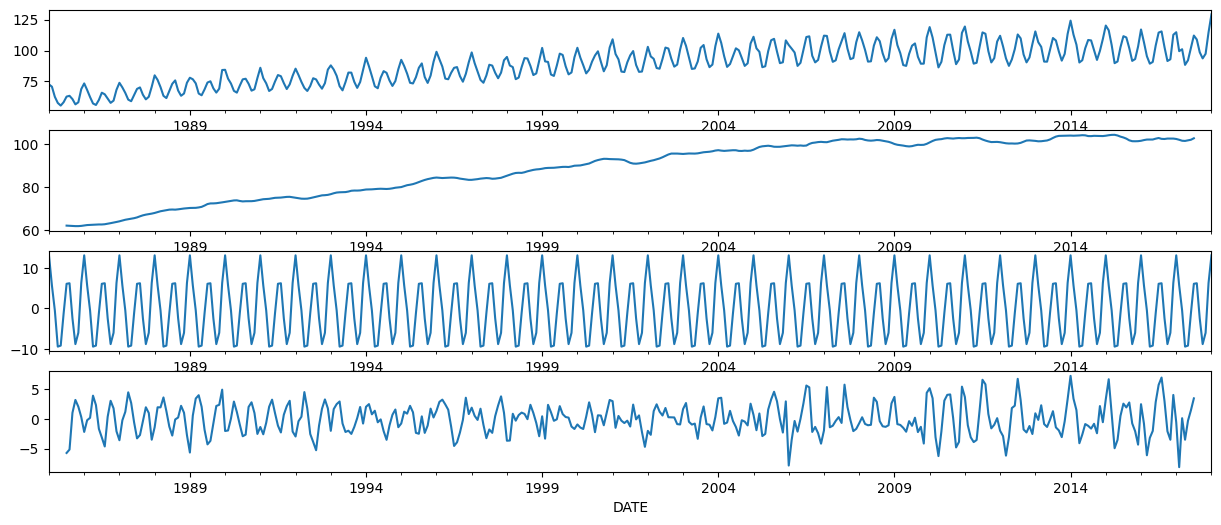

In [15]:
fig,(ax1, ax2, ax3, ax4) = plt.subplots(4,1,figsize=(15,6))
resultados.observed.plot(ax=ax1)
#a curva de tempo e os valores
resultados.trend.plot(ax=ax2)
#tendência vamos que é crescente, constata o crescimento
resultados.seasonal.plot(ax=ax3)
#sazonalidade, se comparar os dois picos que temos, eles se repetem com o tempo
resultados.resid.plot(ax=ax4)
#resíduo
plt.show()

In [16]:
# Estacionaria ou nao estacionaria
# ADF - Augmented Dickey Fuller
# Hipotese nula - H0 (nao é estacionaria)
# Hipotese alternativa - H1 (rejeicao da hipotese nula - é estacionaria)
# p-value = 0.05 (5%), entao rejeitamos H0com um nivel de confianca de 95%

In [17]:
from statsmodels.tsa.stattools import adfuller

In [18]:
sns.set_style("darkgrid") #apenas ajusta o estilo do seaborn

In [19]:
x = eletric.Value.values #extrai os valores (values) da coluna Value
# aqui ele converte para um array NumPy

In [21]:
result = adfuller(x)
#executa o ADF sobre uma série x - o retorno é uma tupla com vários elementos estatísticos

print("Teste ADF")
print(f"Teste Estatistico: {result[0]}") #quanto mais negativa, maior a evidência de estacionária
print(f"P-Value: {result[1]}") # <=0.05 rejeita H0 / >0.05 não rejeita
print("Valores críticos:") #exibe os valores críticos do teste para diferentes níveis de significância

for key, value in result[4].items():
  print(f"\t{key}: {value}")

#como o valor do teste foi maior do que os valores críticos e o p-value doi menor que 0.05
#observamos que não é estacionária

Teste ADF
Teste Estatistico: -2.256990350047235
P-Value: 0.1862146911658712
Valores críticos:
	1%: -3.4476305904172904
	5%: -2.869155980820355
	10%: -2.570827146203181


In [22]:
type(result)

tuple

In [23]:
len(result)

6

In [24]:
result

(np.float64(-2.256990350047235),
 np.float64(0.1862146911658712),
 15,
 381,
 {'1%': np.float64(-3.4476305904172904),
  '5%': np.float64(-2.869155980820355),
  '10%': np.float64(-2.570827146203181)},
 np.float64(1840.8474501627156))

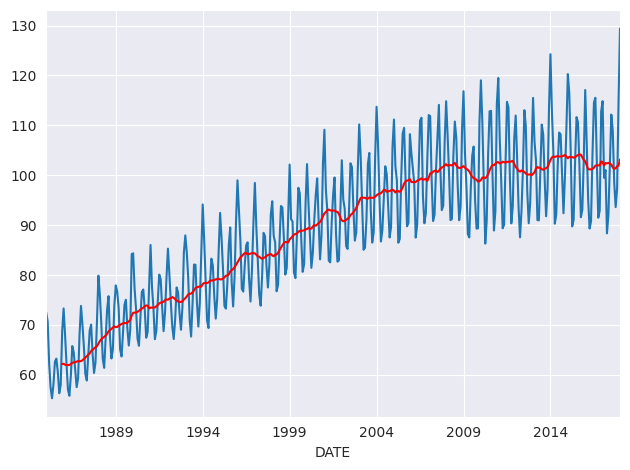

In [26]:
#média movel
#Suavizar a série temporal eletric usando média móvel de 12 períodos
#e comparar visualmente a série original com sua tendência

ma = eletric.rolling(12).mean()
f, ax = plt.subplots()
eletric.plot(ax = ax, legend = False)
ma.plot(ax = ax, legend = False, color='r')
plt.tight_layout()

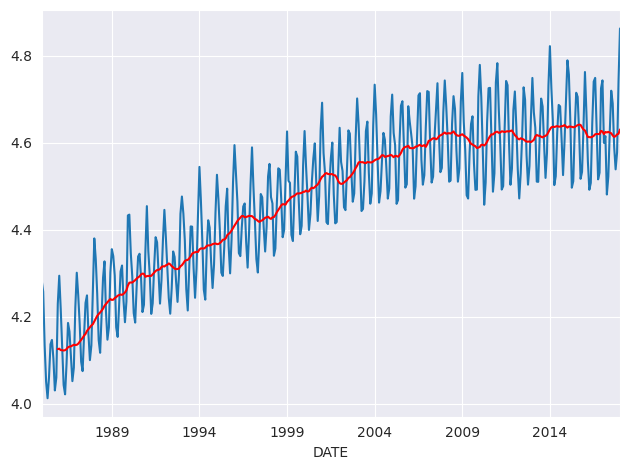

In [28]:
#O log não remove tendência, apenas estabiliza a variância.
#Se a média ainda muda ao longo do tempo, a série continua não estacionária.
df_log = np.log(eletric)
ma_log = df_log.rolling(12).mean()
f, ax = plt.subplots()
df_log.plot(ax = ax, legend = False)
ma_log.plot(ax = ax, legend = False, color='r')
plt.tight_layout()

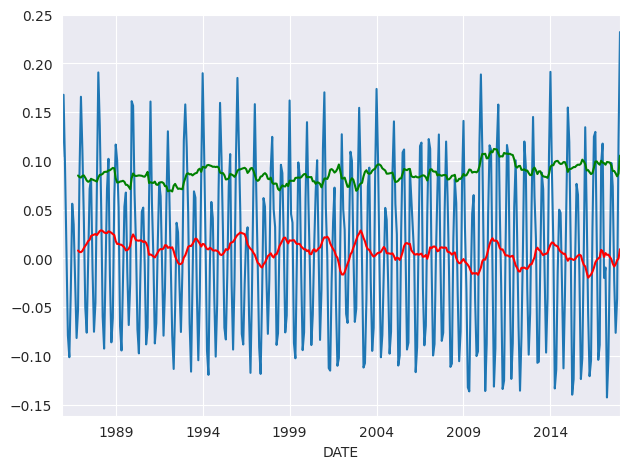

In [29]:
#Remover a tendência da série (em log) e avaliar visualmente se a série resultante apresenta estacionariedade,
#observando média e variância ao longo do tempo.

df_s = (df_log - ma_log).dropna()
#subtrai a média móvel da série em log
#remove o componente de tendência
#série centrada em torno de zero

ma_s = df_s.rolling(12).mean() #usada para verificar se a média permanece constante
std = df_s.rolling(12).std() #usada para avaliar se a variância é constante

f, ax = plt.subplots()
df_s.plot(ax = ax, legend = False)
ma_s.plot(ax = ax, legend = False, color='r')
std.plot(ax = ax, legend = False, color='g')
plt.tight_layout()

In [30]:
x_s = df_s.Value.values
result_s = adfuller(x_s)

print("Teste ADF")
print(f"Teste Estatistico: {result_s[0]}")
print(f"P-Value: {result_s[1]}")
print("Valores críticos:")

for key, value in result_s[4].items():
  print(f"\t{key}: {value}")

Teste ADF
Teste Estatistico: -5.2115861853654355
P-Value: 8.32563975994627e-06
Valores críticos:
	1%: -3.448147967010838
	5%: -2.8693833397824413
	10%: -2.5709483564645725


Teste ADF
Teste Estatistico: -7.651129568145172
P-Value: 1.788126735435739e-11
Valores críticos:
	1%: -3.448294490928673
	5%: -2.869447722240253
	10%: -2.570982681065269


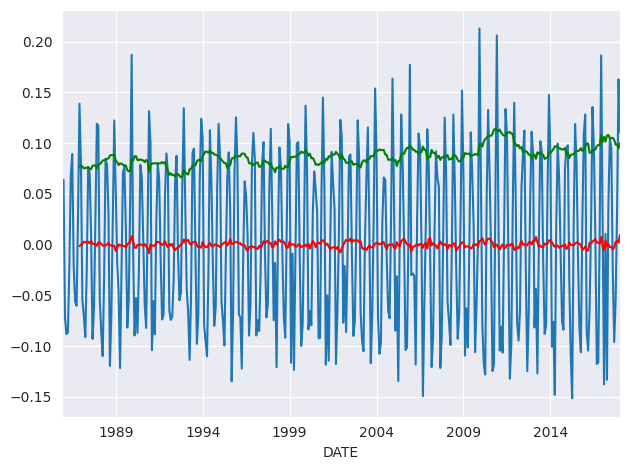

In [32]:
df_diff = df_s.diff(1)
ma_diff = df_diff.rolling(12).mean()
std_diff = df_diff.rolling(12).std()

f, ax = plt.subplots()
df_diff.plot(ax = ax, legend = False)
ma_diff.plot(ax = ax, legend = False, color='r')
std_diff.plot(ax = ax, legend = False, color='g')
plt.tight_layout()

x_diff = df_diff.Value.dropna().values
result_diff = adfuller(x_diff)

print("Teste ADF")
print(f"Teste Estatistico: {result_diff[0]}")
print(f"P-Value: {result_diff[1]}")
print("Valores críticos:")

for key, value in result_diff[4].items():
  print(f"\t{key}: {value}")

In [33]:
from statsmodels.tsa.stattools import acf, pacf

In [34]:
#ARIMA - AR(autoregressivo) I (integrado) MA (moving average)
# A(x,y,z) - ACF, PACF

In [35]:
#nlags=25 avalia correlação da série com seus 25 primeiras defasagens
lag_acf = acf(df_diff.dropna(), nlags = 25)
laf_pacf = pacf(df_diff.dropna(), nlags = 25)

In [36]:
#5% ACF
#1.96/sqrt(N-d) -> N número de pontos do dfe d é o número de vezes que diferenciamos o df

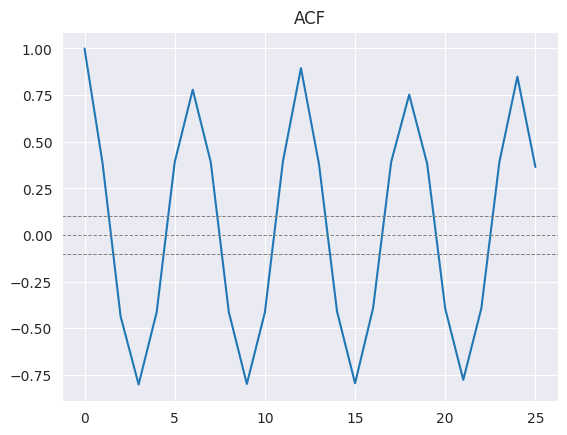

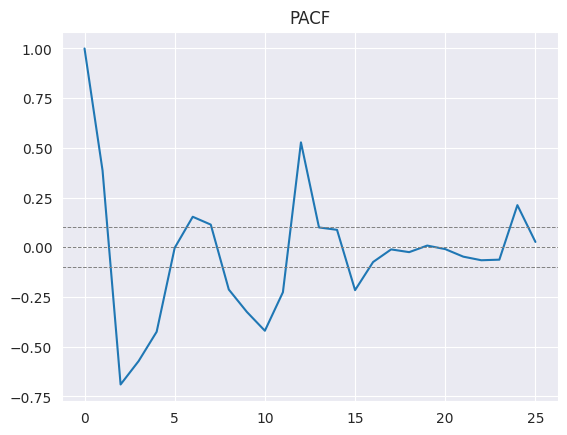

In [37]:
plt.plot(lag_acf)

plt.axhline( y= -1.96/(np.sqrt((len(df_diff)-1))), linestyle = '--', color ='gray', linewidth=0.7)
plt.axhline( y= 0/(np.sqrt((len(df_diff)-1))), linestyle = '--', color ='gray', linewidth=0.7)
plt.axhline( y= 1.96/(np.sqrt((len(df_diff)-1))), linestyle = '--', color ='gray', linewidth=0.7)
plt.title("ACF")
plt.show()

plt.plot(laf_pacf)

plt.axhline( y= -1.96/(np.sqrt((len(df_diff)-1))), linestyle = '--', color ='gray', linewidth=0.7)
plt.axhline( y= 0/(np.sqrt((len(df_diff)-1))), linestyle = '--', color ='gray', linewidth=0.7)
plt.axhline( y= 1.96/(np.sqrt((len(df_diff)-1))), linestyle = '--', color ='gray', linewidth=0.7)

plt.title("PACF")
plt.show()

In [38]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

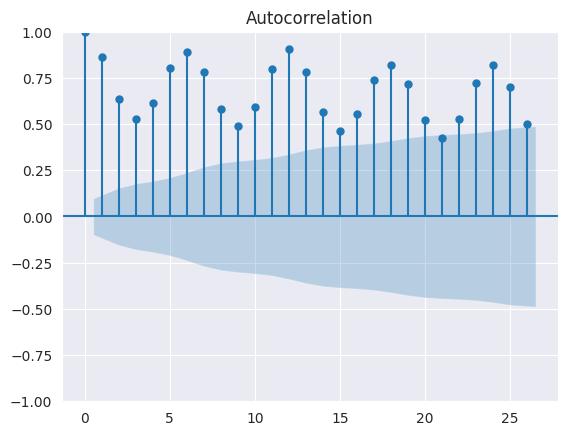

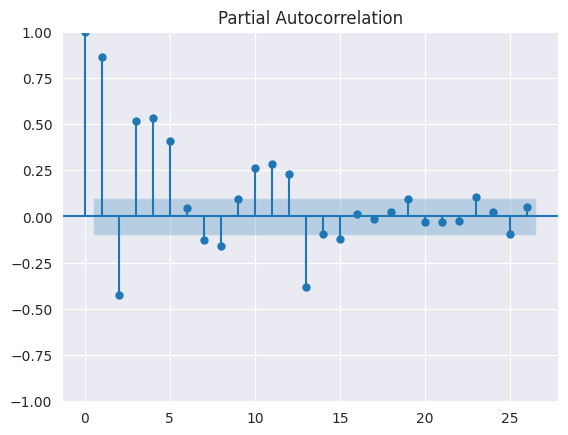

In [40]:
plot_acf(eletric.Value)
plot_pacf(eletric.Value)
plt.show()